In [122]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.dataset import *
from mis_dro.plot import *
from mis_dro.newsvendor import newsvendor_cost_cvxpy

In [123]:
dgp = "contaminated_exp_old"

In [124]:
def process(results_df, dgp, contamination, trim=False):
    results_df = results_df.loc[(results_df["contamination"] == contamination) & (results_df["dgp"] == dgp)]
    if trim:
        results_df = results_df[results_df['epsilon'] < 0.2]  # where to trim the epsilons, adjust accordingly if needed
    gb = results_df.groupby(by=["algorithm", "epsilon", "inference"])
    agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    })
    return agg_df

In [125]:
def plot_df(df, dgp: str, algorithm: str, label: str, axis, shp: str,  marker=False):
    # get a dataframe for each posterior
    df = df.loc[algorithm, :]
    # # mean of variances + variance of means
    bootstrap_var = df["var_cost"]["mean"] + df["mean_cost"]["var"]
    # plot mean-variance trade-off
    axis.plot(bootstrap_var, df["mean_cost"]["mean"], marker=shp, linestyle='solid', label=label)
    # set title and label epsilon
    axis.set_title(f"{dgp}")
    axis.set_xlabel("out-of-sample variance")
    if dgp == (r'$\eta =$' + '0.0'):
        axis.set_ylabel("out-of-sample mean")
        axis.legend()
    if marker:
        for i, epsilon in enumerate(df.index.get_level_values("epsilon")):
            if i % 4 == 0:
                axis.text(bootstrap_var[epsilon], df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')
        # if (i+2) % 4 == 0:
        #     axis.text(empirical_bootstrap_var[epsilon], empirical_df["mean_cost"]["mean"][epsilon], epsilon, ha='right', va='bottom')

In [126]:
experiment_path = Path("/Users/patrick/Experiments/misdro/contaminated_exp_results/")
robas_path = experiment_path/ "results_robas.csv"
robas_df_og = pd.read_csv(robas_path)
other_path = experiment_path / "results_bas_bdro_mmd.csv"
other_df_og = pd.read_csv(other_path)
agg_df_robas = process(robas_df_og, 'contaminated_exp_old', 0, trim=True)
other_df_og["algorithm"].unique()

array(['kl_dro_bas', 'kl_bdro', 'empirical_mmd'], dtype=object)

/opt/anaconda3/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/opt/anaconda3/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
/opt/a

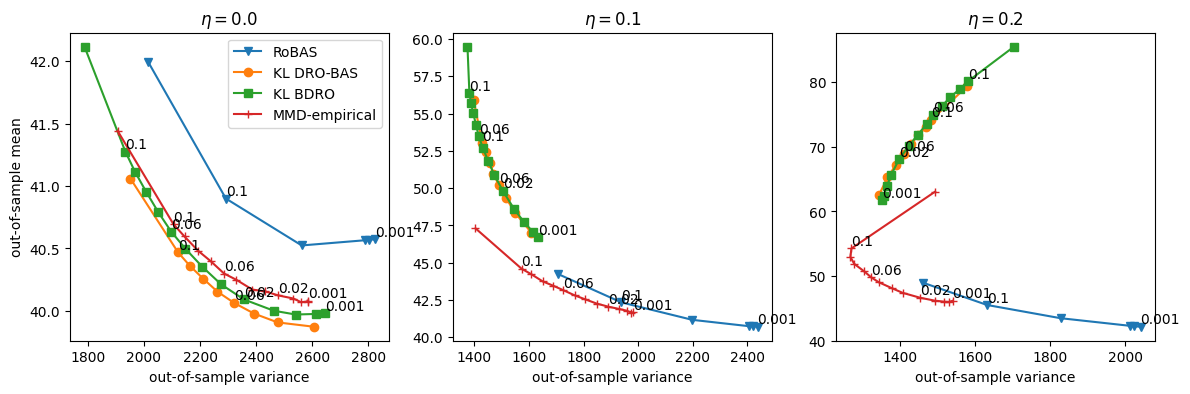

In [127]:
fig, axis = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, figsize=(14,4))
contam_levels = [0.0, 0.1, 0.2]  # all contamination levels

# Marker shapes
shp_bas = 'o'
shp_bdro = 's'
shp_bdro_npl = 'x'
shp_emp = '+'
shp_robas = 'v'

for i, contam in enumerate(contam_levels):
    agg_df_robas = process(robas_df_og, 'contaminated_exp_old', contam, trim=True)
    agg_kl_bas = process(other_df_og.loc[other_df_og["algorithm"] == "kl_dro_bas"], "contaminated_exp_old", contam, trim=True)
    agg_kl_bdro = process(other_df_og.loc[other_df_og["algorithm"] == "kl_bdro"], "contaminated_exp_old", contam, trim=True)
    agg_mmd_emp = process(other_df_og.loc[other_df_og["algorithm"] == "empirical_mmd"], "contaminated_exp_old", contam, trim=True)

    # agg_df_kl = process(experiment_path_kl, 'bimodal_univariate_gaussian', contam, trim=True)  
    # agg_df_emp = process(experiment_path_emp, 'bimodal_univariate_gaussian', contam,trim=True)
    
    # agg_df_bdro_npl = process(experiment_path_bdro_npl, 'bimodal_univariate_gaussian', contam,trim=True)
    # plot_df(agg_df_kl, r'$\eta =$' + f'{contam}', 'kl_dro_bas', 'DRO-BAS', axis[i], shp_bas)
    # plot_df(agg_df_kl, r'$\eta =$' + f'{contam}', 'kl_bdro', 'BDRO', axis[i], shp_bdro, marker=True)
    # plot_df(agg_df_bdro_npl, r'$\eta =$' + f'{contam}', 'kl_bdro', 'BDRO-NPL', axis[i], shp_bdro_npl)
    # plot_df(agg_df_emp, r'$\eta =$' + f'{contam}', 'empirical_mmd', 'MMD-empirical', axis[i], shp_emp)
    plot_df(agg_df_robas,r'$\eta =$' + f'{contam}', 'dro_bas_mmd', 'RoBAS', axis[i], shp_robas, marker=True)
    plot_df(agg_kl_bas, r'$\eta =$' + f'{contam}', "kl_dro_bas", "KL DRO-BAS", axis[i], shp_bas, marker=True)
    plot_df(agg_kl_bdro, r'$\eta =$' + f'{contam}', "kl_bdro", "KL BDRO", axis[i], shp_bdro, marker=True)
    plot_df(agg_mmd_emp, r'$\eta =$' + f'{contam}', "empirical_mmd", "MMD-empirical", axis[i], shp_emp, marker=True)

In [163]:
results_df = pd.concat([robas_df_og, other_df_og])
print("DGP:", results_df["dgp"].unique())
print("num_observations", results_df["num_observations"].unique())
print("likelihood", results_df["likelihood"].unique())
print("posterior", results_df["posterior"].unique())

DGP: ['contaminated_exp_old']
num_observations [20]
likelihood ['exponential' 'empirical']
posterior ['npl' 'gamma']


In [134]:
num_observations = robas_df_og["num_observations"].unique()[0]
num_test_observations = robas_df_og["num_test_observations"].unique()[0]
dim = 1
epsilon_list = robas_df_og["epsilon"].unique()
results_df = pd.concat([robas_df_og, other_df_og])

num_observations = results_df["num_observations"].unique()[0]
num_test_observations = results_df["num_test_observations"].unique()[0]
single_test_observation = []

h_set = []  # if x > xi, then the solution belongs to the h set. NOTE h = 3
b_set = []  # if x < xi, then the solution belongs to the b set. NOTE b = 8

for idx, df in results_df.groupby(["algorithm", "contamination", "epsilon", "inference", "replication"]):
# for algorithm in results_df["algorithm"].unique():
#     for contamination in results_df["contamination"].unique():
#         for epsilon in epsilon_list:
#             for replication in range(200):
    algorithm, contamination, epsilon, inference, replication = idx
    generator = np.random.default_rng(seed=replication)
    # NOTE if contamination is specified, then only contaminate the training samples (not test samples)
    data = sample_dgp(
        dgp, num_observations, dim=dim, contamination=contamination, generator=generator
    )
    data_eval = sample_dgp(
        dgp, num_test_observations, dim=dim, contamination=0.0, generator=generator
    )
    # df = results_df.loc[(results_df["algorithm"] == algorithm) & (results_df["epsilon"] == epsilon) & (results_df["replication"] == replication) & (results_df["contamination"] == contamination)]

    x = df["solution"].iloc[0]
    x = np.array([float(x) for x in df["solution"].iloc[0].strip('[]').split(',')])
    xi = data_eval[0].reshape((1,1))
    # print("x", x.shape)
    # print("xi", xi)
    single_test_observation.append({
        "algorithm": algorithm,
        "dgp": dgp,
        "epsilon": epsilon,
        "inference": inference,
        "contamination": contamination,
        "replication": replication,
        "solution": x,
        "xi": xi,
        "objective": newsvendor_cost_cvxpy(x, xi).value[0],
    })
    if x < xi:
        b_set.append({
            "algorithm": algorithm,
            "dgp": dgp,
            "epsilon": epsilon,
            "inference": inference,
            "contamination": contamination,
            "replication": replication,
            "solution": x,
            "xi": xi,
            "objective": newsvendor_cost_cvxpy(x, xi).value[0],
        })
    else:
        h_set.append({
            "algorithm": algorithm,
            "dgp": dgp,
            "epsilon": epsilon,
            "inference": inference,
            "contamination": contamination,
            "replication": replication,
            "solution": x,
            "xi": xi,
            "objective": newsvendor_cost_cvxpy(x, xi).value[0],
        })



In [136]:
h_df = pd.DataFrame(h_set)
b_df = pd.DataFrame(b_set)
one_df = pd.DataFrame(single_test_observation)
h_df.shape, b_df.shape, one_df.shape


((25637, 9), (2863, 9), (28500, 9))

In [145]:
def process_one_sample(results_df, dgp, contamination, trim=False):
    results_df = results_df.loc[(results_df["contamination"] == contamination) & (results_df["dgp"] == dgp)]
    if trim:
        results_df = results_df[results_df['epsilon'] < 0.2]  # where to trim the epsilons, adjust accordingly if needed
    gb = results_df.groupby(by=["algorithm", "epsilon", "inference"])
    agg_df = gb.agg({
        "objective": ["mean", "var"],
    })
    return agg_df

def one_plot_df(df, dgp: str, algorithm: str, label: str, axis, shp: str,  marker=False):
    # get a dataframe for each posterior
    df = df.loc[algorithm, :]
    # plot mean-variance trade-off
    axis.plot(df["objective"]["var"], df["objective"]["mean"], marker=shp, linestyle='solid', label=label)
    # set title and label epsilon
    axis.set_title(f"{dgp}")
    axis.set_xlabel("out-of-sample variance")
    if dgp == (r'$\eta =$' + '0.0'):
        axis.set_ylabel("out-of-sample mean")
        axis.legend()
    if marker:
        for i, epsilon in enumerate(df.index.get_level_values("epsilon")):
            if i % 4 == 0:
                axis.text(df["objective"]["var"][epsilon], df["objective"]["mean"][epsilon], epsilon, ha='left', va='bottom')



In [146]:
one_df["algorithm"].unique()

array(['dro_bas_mmd', 'empirical_mmd', 'kl_bdro', 'kl_dro_bas'],
      dtype=object)

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_10322/2061714918.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/opt/anaconda3/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:753: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
/opt/anaconda3/envs/mis-dro/lib/python3.11/site-packages/matplotlib/text.py:754: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be fi

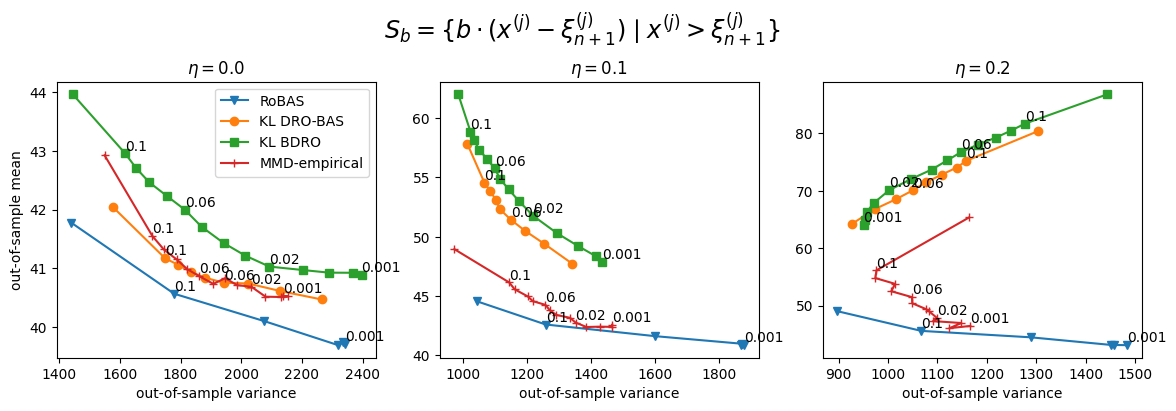

In [164]:
fig, axis = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, figsize=(14,4))
contam_levels = [0.0, 0.1, 0.2]  # all contamination levels

# Marker shapes
shp_bas = 'o'
shp_bdro = 's'
shp_bdro_npl = 'x'
shp_emp = '+'
shp_robas = 'v'

base_df = one_df

for i, contam in enumerate(contam_levels):
    agg_df_robas = process_one_sample(base_df.loc[base_df["algorithm"] == "dro_bas_mmd"], dgp, contam, trim=True)
    agg_kl_bas = process_one_sample(base_df.loc[base_df["algorithm"] == "kl_dro_bas"], dgp, contam, trim=True)
    agg_kl_bdro = process_one_sample(base_df.loc[base_df["algorithm"] == "kl_bdro"], dgp, contam, trim=True)
    agg_mmd_emp = process_one_sample(base_df.loc[base_df["algorithm"] == "empirical_mmd"], dgp, contam, trim=True)

    # agg_df_kl = process(experiment_path_kl, 'bimodal_univariate_gaussian', contam, trim=True)  
    # agg_df_emp = process(experiment_path_emp, 'bimodal_univariate_gaussian', contam,trim=True)
    
    # agg_df_bdro_npl = process(experiment_path_bdro_npl, 'bimodal_univariate_gaussian', contam,trim=True)
    # plot_df(agg_df_kl, r'$\eta =$' + f'{contam}', 'kl_dro_bas', 'DRO-BAS', axis[i], shp_bas)
    # plot_df(agg_df_kl, r'$\eta =$' + f'{contam}', 'kl_bdro', 'BDRO', axis[i], shp_bdro, marker=True)
    # plot_df(agg_df_bdro_npl, r'$\eta =$' + f'{contam}', 'kl_bdro', 'BDRO-NPL', axis[i], shp_bdro_npl)
    # plot_df(agg_df_emp, r'$\eta =$' + f'{contam}', 'empirical_mmd', 'MMD-empirical', axis[i], shp_emp)
    one_plot_df(agg_df_robas,r'$\eta =$' + f'{contam}', 'dro_bas_mmd', 'RoBAS', axis[i], shp_robas, marker=True)
    one_plot_df(agg_kl_bas, r'$\eta =$' + f'{contam}', "kl_dro_bas", "KL DRO-BAS", axis[i], shp_bas, marker=True)
    one_plot_df(agg_kl_bdro, r'$\eta =$' + f'{contam}', "kl_bdro", "KL BDRO", axis[i], shp_bdro, marker=True)
    one_plot_df(agg_mmd_emp, r'$\eta =$' + f'{contam}', "empirical_mmd", "MMD-empirical", axis[i], shp_emp, marker=True)

fig.subplots_adjust(top=0.8)
# fig.suptitle(r"$S_h = \{ h \cdot ( x^{(j)} - \xi_{n+1}^{(j)}) \mid x^{(j)} > \xi_{n+1}^{(j)} \}$", fontsize="xx-large")
fig.suptitle(r"$S_b = \{ b \cdot ( x^{(j)} - \xi_{n+1}^{(j)}) \mid x^{(j)} > \xi_{n+1}^{(j)} \}$", fontsize="xx-large")

fig.show()

In [ ]:
I plotted “variance split” metric in two separate plots. Set S_b contains the objective f(x, xi) when x>xi. Set S_h contains the objective when x<xi. I don’t see any pattern here really, no nice curve.